In [ ]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"sheetalshende05","key":"45ca1a67c2558a37f77a05f899b73f1b"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets list -s audio

ref                                                      title                                                   size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------------------------------  -----------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
uwrfkaggler/ravdess-emotional-speech-audio               RAVDESS Emotional speech audio                     450102890  2019-01-19 18:28:31.433000         109174        729  0.875            
sripaadsrinivasan/audio-mnist                            Audio MNIST                                        994530111  2020-12-28 07:34:33.170000           7475         74  0.875            
mmoreaux/audio-cats-and-dogs                             Audio Cats and Dogs                                101721956  2017-10-05 09:40:26.727000          19058        289  0.7647059        
uldisvalainis/audio-emotions                 

In [ ]:
!kaggle datasets download -d mohammedabdeldayem/the-fake-or-real-dataset

Dataset URL: https://www.kaggle.com/datasets/mohammedabdeldayem/the-fake-or-real-dataset
License(s): GNU Lesser General Public License 3.0
100% 16.0G/16.0G [06:39<00:00, 43.0MB/s]



In [ ]:
!unzip -q the-fake-or-real-dataset.zip -d dataset

In [ ]:
import os

for root, dirs, files in os.walk("dataset"):
    print(root)
    print("Folders:", len(dirs))
    print("Files:", len(files))
    print("-"*50)

dataset
Folders: 4
Files: 0
--------------------------------------------------
dataset/for-original
Folders: 1
Files: 0
--------------------------------------------------
dataset/for-original/for-original
Folders: 3
Files: 0
--------------------------------------------------
dataset/for-original/for-original/validation
Folders: 2
Files: 0
--------------------------------------------------
dataset/for-original/for-original/validation/real
Folders: 0
Files: 5400
--------------------------------------------------
dataset/for-original/for-original/validation/fake
Folders: 0
Files: 5400
--------------------------------------------------
dataset/for-original/for-original/testing
Folders: 2
Files: 0
--------------------------------------------------
dataset/for-original/for-original/testing/real
Folders: 0
Files: 2264
--------------------------------------------------
dataset/for-original/for-original/testing/fake
Folders: 0
Files: 2370
--------------------------------------------------
datas

In [ ]:
!pip install librosa -q

In [ ]:
import os

real_path = "dataset/for-norm/for-norm/training/real"
fake_path = "dataset/for-norm/for-norm/training/fake"

real_file = os.path.join(real_path, os.listdir(real_path)[0])
fake_file = os.path.join(fake_path, os.listdir(fake_path)[0])

print("Real Audio:")
print(real_file)

print("\nFake Audio:")
print(fake_file)

Real Audio:
dataset/for-norm/for-norm/training/real/file8514.wav_16k.wav_norm.wav_mono.wav_silence.wav

Fake Audio:
dataset/for-norm/for-norm/training/fake/file26787.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav


In [ ]:
import librosa

audio, sr = librosa.load(real_file, sr=None)

print("Sampling Rate:", sr)
print("Number of Samples:", len(audio))
print("Duration:", len(audio)/sr, "seconds")

Sampling Rate: 16000
Number of Samples: 56016
Duration: 3.501 seconds


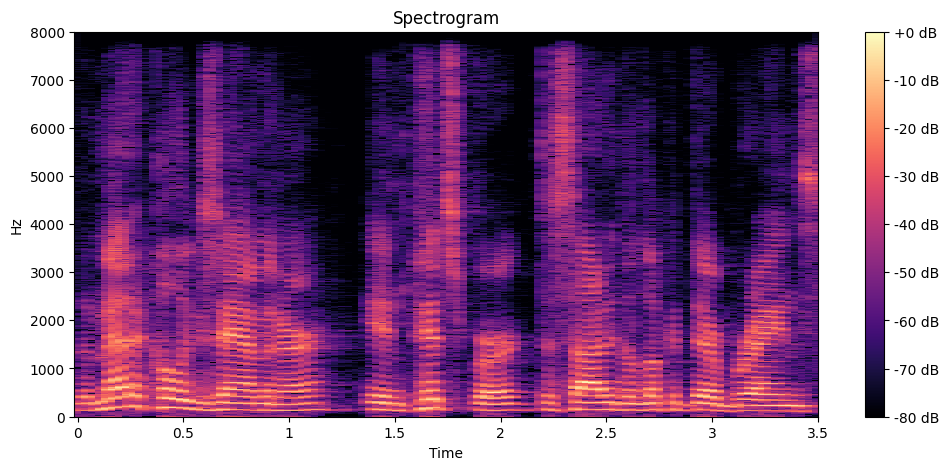

In [ ]:

import librosa.display
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12,5))

D = librosa.amplitude_to_db(
    abs(librosa.stft(audio)),
    ref=np.max
)

librosa.display.specshow(
    D,
    sr=sr,
    x_axis='time',
    y_axis='hz'
)

plt.colorbar(format='%+2.0f dB')
plt.title("Spectrogram")
plt.show()

MFCC Shape: (13, 110)


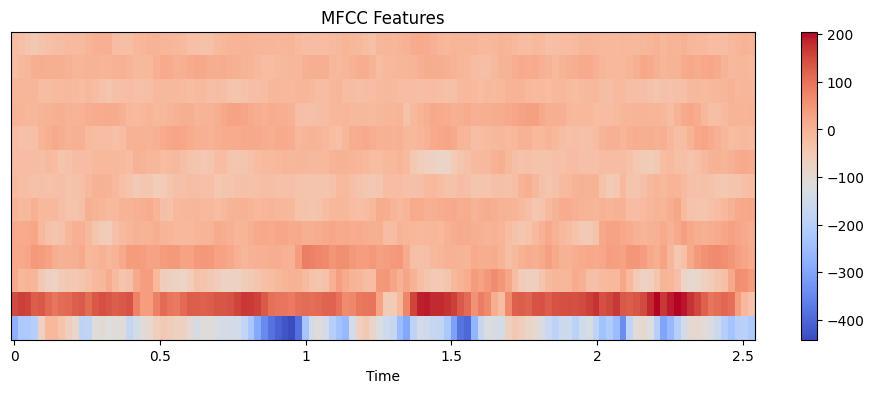

In [ ]:
mfcc = librosa.feature.mfcc(
    y=audio,
    sr=sr,
    n_mfcc=13
)

print("MFCC Shape:", mfcc.shape)
plt.figure(figsize=(12,4))

librosa.display.specshow(
    mfcc,
    x_axis='time'
)

plt.colorbar()
plt.title("MFCC Features")
plt.show()

In [ ]:
import os

real_path = "dataset/for-norm/for-norm/training/real"
fake_path = "dataset/for-norm/for-norm/training/fake"

real_files = [os.path.join(real_path,f) for f in os.listdir(real_path)[:5000]]
fake_files = [os.path.join(fake_path,f) for f in os.listdir(fake_path)[:5000]]

print("Real Files:", len(real_files))
print("Fake Files:", len(fake_files))

Real Files: 5000
Fake Files: 5000


In [ ]:
# cell2
import os

test_real_path = "dataset/for-norm/for-norm/testing/real"
test_fake_path = "dataset/for-norm/for-norm/testing/fake"

print("Real test files:", len(os.listdir(test_real_path)))
print("Fake test files:", len(os.listdir(test_fake_path)))

Real test files: 2264
Fake test files: 2370


In [ ]:
# cell3
X = []
y = []

def extract_features(file_path):

    audio, sr = librosa.load(file_path, sr=None)

    # Fix empty or too-short audio
    if len(audio) == 0:
        audio = np.zeros(2048)

    if len(audio) < 2048:
        audio = np.pad(audio, (0, 2048 - len(audio)))

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=40
    )

    if mfcc.shape[1] >= 9:
        delta = librosa.feature.delta(mfcc)
        delta2 = librosa.feature.delta(mfcc, order=2)
    else:
        delta = np.zeros_like(mfcc)
        delta2 = np.zeros_like(mfcc)

    try:
        chroma = librosa.feature.chroma_stft(y=audio, sr=sr)
    except:
        chroma = np.zeros((12, 1))

    spectral_centroid = librosa.feature.spectral_centroid(y=audio, sr=sr)
    spectral_bandwidth = librosa.feature.spectral_bandwidth(y=audio, sr=sr)
    spectral_rolloff = librosa.feature.spectral_rolloff(y=audio, sr=sr)
    zcr = librosa.feature.zero_crossing_rate(audio)
    rms = librosa.feature.rms(y=audio)

    features = np.hstack([
        np.mean(mfcc, axis=1),
        np.mean(delta, axis=1),
        np.mean(delta2, axis=1),
        np.mean(chroma, axis=1),
        np.mean(spectral_centroid),
        np.mean(spectral_bandwidth),
        np.mean(spectral_rolloff),
        np.mean(zcr),
        np.mean(rms)
    ])

    return features

for file in real_files:
    X.append(extract_features(file))
    y.append(0)

for file in fake_files:
    X.append(extract_features(file))
    y.append(1)

X = np.array(X)
y = np.array(y)

print("Feature Matrix Shape:", X.shape)
print("Labels Shape:", y.shape)


/usr/local/lib/python3.12/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


Feature Matrix Shape: (10000, 137)
Labels Shape: (10000,)


In [ ]:
# cell4
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

XGBoost

In [ ]:
!pip install xgboost -q

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=10,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X, y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=-1, num_parallel_tree=None, ...)

LightGBM


In [ ]:
!pip install lightgbm -q
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

lgbm.fit(X, y)

[LightGBM] [Info] Number of positive: 5000, number of negative: 5000
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015193 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 34935
[LightGBM] [Info] Number of data points in the train set: 10000, number of used features: 137
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


LGBMClassifier(learning_rate=0.05, n_estimators=300, random_state=42)

validation


In [ ]:
# Cell 5: Validation feature extraction

import os
import numpy as np
from tqdm import tqdm

val_real_path = "dataset/for-norm/for-norm/validation/real"
val_fake_path = "dataset/for-norm/for-norm/validation/fake"

val_real_files = [
    os.path.join(val_real_path, f)
    for f in os.listdir(val_real_path)
]

val_fake_files = [
    os.path.join(val_fake_path, f)
    for f in os.listdir(val_fake_path)
]

print("Validation real files:", len(val_real_files))
print("Validation fake files:", len(val_fake_files))

X_val = []
y_val = []

for file in tqdm(val_real_files):
    X_val.append(extract_features(file))
    y_val.append(0)

for file in tqdm(val_fake_files):
    X_val.append(extract_features(file))
    y_val.append(1)

X_val = np.array(X_val)
y_val = np.array(y_val)

print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

Validation real files: 5400
Validation fake files: 5398


  3%|▎         | 150/5400 [00:07<03:43, 23.50it/s]/usr/local/lib/python3.12/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
 29%|██▉       | 1587/5400 [01:20<02:51, 22.23it/s]/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1690
  warnings.warn(
100%|██████████| 5398/5398 [02:32<00:00, 35.48it/s]

X_val shape: (10798, 137)
y_val shape: (10798,)


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

rf_val_pred = rf.predict(X_val)

print("========== RANDOM FOREST VALIDATION ==========")
print("Accuracy:", accuracy_score(y_val, rf_val_pred))
print(classification_report(y_val, rf_val_pred))

xgb_val_pred = xgb.predict(X_val)

print("========== XGBOOST VALIDATION ==========")
print("Accuracy:", accuracy_score(y_val, xgb_val_pred))
print(classification_report(y_val, xgb_val_pred))

lgbm_pred = lgbm.predict(X_val)

print("========== LIGHTGBM VALIDATION ==========")
print("Accuracy:", accuracy_score(y_val, lgbm_pred))
print(classification_report(y_val, lgbm_pred))

========== RANDOM FOREST VALIDATION ==========
Accuracy: 0.9498981292832006
              precision    recall  f1-score   support

           0       0.97      0.92      0.95      5400
           1       0.93      0.98      0.95      5398

    accuracy                           0.95     10798
   macro avg       0.95      0.95      0.95     10798
weighted avg       0.95      0.95      0.95     10798

========== XGBOOST VALIDATION ==========
Accuracy: 0.9865715873309873
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      5400
           1       0.98      0.99      0.99      5398

    accuracy                           0.99     10798
   macro avg       0.99      0.99      0.99     10798
weighted avg       0.99      0.99      0.99     10798



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


========== LIGHTGBM VALIDATION ==========
Accuracy: 0.9911094647156881
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      5400
           1       0.99      1.00      0.99      5398

    accuracy                           0.99     10798
   macro avg       0.99      0.99      0.99     10798
weighted avg       0.99      0.99      0.99     10798



### Model Validation Results
10,000 training data

| Model         | Accuracy | Precision | Recall | F1-Score |
|--------------|----------|-----------|--------|----------|
| Random Forest | 94.99% | 0.95 | 0.95 | 0.95 |
| XGBoost | 98.66% | 0.99 | 0.99 | 0.99 |
| LightGBM | 99.11% | 0.99 | 0.99 | 0.99 |

**Observation:** LightGBM achieved the highest accuracy (99.11%) and showed the best overall performance for deepfake audio detection.

EER




In [ ]:
from sklearn.metrics import roc_curve
import numpy as np

def calculate_eer(y_true, y_scores):

    fpr, tpr, thresholds = roc_curve(y_true, y_scores)

    fnr = 1 - tpr

    eer_idx = np.nanargmin(np.absolute(fnr - fpr))

    eer = (fpr[eer_idx] + fnr[eer_idx]) / 2

    return eer * 100

# Random Forest
rf_probs = rf.predict_proba(X_val)[:,1]
rf_eer = calculate_eer(y_val, rf_probs)

print("RF EER:", round(rf_eer, 2), "%")


# XGBoost
xgb_probs = xgb.predict_proba(X_val)[:,1]
xgb_eer = calculate_eer(y_val, xgb_probs)

print("XGB EER:", round(xgb_eer, 2), "%")


# LightGBM
lgbm_probs = lgbm.predict_proba(X_val)[:,1]
lgbm_eer = calculate_eer(y_val, lgbm_probs)

print("LGBM EER:", round(lgbm_eer, 2), "%")

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

ensemble_probs = (
    xgb.predict_proba(X_val)[:,1]
    +
    lgbm.predict_proba(X_val)[:,1]
) / 2

ensemble_pred = (ensemble_probs > 0.5).astype(int)

print("========== ENSEMBLE VALIDATION ==========")

print(
    "Accuracy:",
    accuracy_score(y_val, ensemble_pred)
)

print(
    classification_report(
        y_val,
        ensemble_pred
    )
)

In [ ]:
ensemble_eer = calculate_eer(
    y_val,
    ensemble_probs
)

print(
    "Ensemble EER:",
    round(ensemble_eer, 2),
    "%"
)

ensemble eer>lightgbm eer
hence lightgbm is better

In [ ]:
# cell5
import os
import numpy as np
import librosa
from tqdm import tqdm

test_real_files = [
    os.path.join(test_real_path, f)
    for f in os.listdir(test_real_path)
]

test_fake_files = [
    os.path.join(test_fake_path, f)
    for f in os.listdir(test_fake_path)
]

X_test = []
y_test = []

def extract_features(file_path):

    audio, sr = librosa.load(file_path, sr=None)

    # MFCC
    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=40
    )

    # Delta and Delta-Delta
    if mfcc.shape[1] >= 9:
        delta = librosa.feature.delta(mfcc)
        delta2 = librosa.feature.delta(mfcc, order=2)
    else:
        delta = np.zeros_like(mfcc)
        delta2 = np.zeros_like(mfcc)

    # Chroma
    chroma = librosa.feature.chroma_stft(
        y=audio,
        sr=sr
    )

    # Spectral Features
    spectral_centroid = librosa.feature.spectral_centroid(
        y=audio,
        sr=sr
    )

    spectral_bandwidth = librosa.feature.spectral_bandwidth(
        y=audio,
        sr=sr
    )

    spectral_rolloff = librosa.feature.spectral_rolloff(
        y=audio,
        sr=sr
    )

    # Zero Crossing Rate
    zcr = librosa.feature.zero_crossing_rate(audio)

    # RMS Energy
    rms = librosa.feature.rms(y=audio)

    # Combine all features
    features = np.hstack([

        np.mean(mfcc, axis=1),          # 40
        np.mean(delta, axis=1),         # 40
        np.mean(delta2, axis=1),        # 40

        np.mean(chroma, axis=1),        # 12

        np.mean(spectral_centroid),     # 1
        np.mean(spectral_bandwidth),    # 1
        np.mean(spectral_rolloff),      # 1

        np.mean(zcr),                   # 1
        np.mean(rms)                    # 1
    ])

    return features
for file in tqdm(test_real_files):
    X_test.append(extract_features(file))
    y_test.append(0)

for file in tqdm(test_fake_files):
    X_test.append(extract_features(file))
    y_test.append(1)

X_test = np.array(X_test)
y_test = np.array(y_test)

print(X_test.shape)
print(y_test.shape)

 28%|██▊       | 631/2264 [00:30<01:19, 20.58it/s]


KeyboardInterrupt: 

In [ ]:
best_model=lgbm
def predict_audio(file_path):

    features = extract_features(file_path)

    features = features.reshape(1, -1)

    prediction = best_model.predict(features)[0]

    confidence = np.max(best_model.predict_proba(features))

    label = "REAL AUDIO" if prediction == 0 else "FAKE AUDIO"

    return label, confidence

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = best_model.predict(X_test)

print("========== best model TEST ==========")

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred)
)

print(
    classification_report(
        y_test,
        y_pred
    )
)

test_probs = best_model.predict_proba(X_test)[:,1]

test_eer = calculate_eer(
    y_test,
    test_probs
)

print("Test EER:", round(test_eer, 2), "%")


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Real", "Fake"],
    yticklabels=["Real", "Fake"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (tested on Test data)")
plt.show()

In [ ]:
import joblib

joblib.dump(best_model,
            "deepfake_audio_detector_lgbm(18%).pkl")

print("Model saved")

from google.colab import files

files.download(
    "deepfake_audio_detector_lgbm(18%).pkl"
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!mkdir -p /content/drive/MyDrive/DeepfakeProject/kaggle
!cp kaggle.json /content/drive/MyDrive/DeepfakeProject/kaggle/
!cp -r dataset /content/drive/MyDrive/DeepfakeProject/

In [ ]:
from google.colab import files
files.upload()

!mkdir -p /content/drive/MyDrive/DeepfakeProject/models
!cp "deepfake_audio_detector_lgbm(18%).pkl" \
/content/drive/MyDrive/DeepfakeProject/models/

In [ ]:
!mkdir -p /content/drive/MyDrive/DeepfakeProject

!cp the-fake-or-real-dataset.zip \
/content/drive/MyDrive/DeepfakeProject/

In [ ]:
!ls -lh /content/drive/MyDrive/DeepfakeProject/

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!ls -lh /content/drive/MyDrive/DeepfakeProject/kaggle
!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/DeepfakeProject/kaggle/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d mohammedabdeldayem/the-fake-or-real-dataset
!unzip -q the-fake-or-real-dataset.zip -d dataset

In [ ]:
!ls -lh the-fake-or-real-dataset.zip

In [ ]:
!find /content/drive/MyDrive/DeepfakeProject -maxdepth 2 -type f
!du -sh /content/drive/MyDrive/DeepfakeProject/*

In [ ]:
!find /content/drive/MyDrive -name "the-fake-or-real-dataset.zip"

In [ ]:
!unzip -oq the-fake-or-real-dataset.zip -d dataset

In [ ]:
import os

print(len(os.listdir("dataset/for-norm/for-norm/training/real")))
print(len(os.listdir("dataset/for-norm/for-norm/training/fake")))

In [ ]:
!find /content/drive/MyDrive/DeepfakeProject/dataset -type f | wc -l

In [ ]:
import os

real_path = "dataset/for-norm/for-norm/training/real"
fake_path = "dataset/for-norm/for-norm/training/fake"

val_real_path = "dataset/for-norm/for-norm/validation/real"
val_fake_path = "dataset/for-norm/for-norm/validation/fake"

test_real_path = "dataset/for-norm/for-norm/testing/real"
test_fake_path = "dataset/for-norm/for-norm/testing/fake"

print("Train Real:", len(os.listdir(real_path)))
print("Train Fake:", len(os.listdir(fake_path)))

In [ ]:
real_files = [
    os.path.join(real_path, f)
    for f in os.listdir(real_path)[:10000]
]

fake_files = [
    os.path.join(fake_path, f)
    for f in os.listdir(fake_path)[:10000]
]

print("Real Files:", len(real_files))
print("Fake Files:", len(fake_files))

In [ ]:
import os
import numpy as np
import librosa
import librosa.display
from tqdm import tqdm
X = []
y = []

def extract_features(file_path):

    audio, sr = librosa.load(file_path, sr=None)

    # Fix empty or too-short audio
    if len(audio) == 0:
        audio = np.zeros(2048)

    if len(audio) < 2048:
        audio = np.pad(audio, (0, 2048 - len(audio)))

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=40
    )

    if mfcc.shape[1] >= 9:
        delta = librosa.feature.delta(mfcc)
        delta2 = librosa.feature.delta(mfcc, order=2)
    else:
        delta = np.zeros_like(mfcc)
        delta2 = np.zeros_like(mfcc)

    try:
        chroma = librosa.feature.chroma_stft(y=audio, sr=sr)
    except:
        chroma = np.zeros((12, 1))

    spectral_centroid = librosa.feature.spectral_centroid(y=audio, sr=sr)
    spectral_bandwidth = librosa.feature.spectral_bandwidth(y=audio, sr=sr)
    spectral_rolloff = librosa.feature.spectral_rolloff(y=audio, sr=sr)
    zcr = librosa.feature.zero_crossing_rate(audio)
    rms = librosa.feature.rms(y=audio)

    features = np.hstack([
        np.mean(mfcc, axis=1),
        np.mean(delta, axis=1),
        np.mean(delta2, axis=1),
        np.mean(chroma, axis=1),
        np.mean(spectral_centroid),
        np.mean(spectral_bandwidth),
        np.mean(spectral_rolloff),
        np.mean(zcr),
        np.mean(rms)
    ])

    return features

from tqdm import tqdm

for file in tqdm(real_files):
    X.append(extract_features(file))
    y.append(0)

for file in tqdm(fake_files):
    X.append(extract_features(file))
    y.append(1)

X = np.array(X)
y = np.array(y)

print("Feature Matrix Shape:", X.shape)
print("Labels Shape:", y.shape)


In [ ]:
import numpy as np

np.save(
    "/content/drive/MyDrive/DeepfakeProject/X_20k.npy",
    X
)

np.save(
    "/content/drive/MyDrive/DeepfakeProject/y_20k.npy",
    y
)

print("X_20k and y_20k saved successfully!")

In [ ]:
!ls -lh /content/drive/MyDrive/DeepfakeProject/*.npy

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)
print("Random Forest trained")


# XGBoost
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X, y)
print("XGBoost trained")


# LightGBM
lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

lgbm.fit(X, y)
print("LightGBM trained")

In [ ]:
import os
import numpy as np
from tqdm import tqdm

val_real_path = "dataset/for-norm/for-norm/validation/real"
val_fake_path = "dataset/for-norm/for-norm/validation/fake"

val_real_files = [
    os.path.join(val_real_path, f)
    for f in os.listdir(val_real_path)
]

val_fake_files = [
    os.path.join(val_fake_path, f)
    for f in os.listdir(val_fake_path)
]

print("Validation real:", len(val_real_files))
print("Validation fake:", len(val_fake_files))

X_val = []
y_val = []

for file in tqdm(val_real_files):
    X_val.append(extract_features(file))
    y_val.append(0)

for file in tqdm(val_fake_files):
    X_val.append(extract_features(file))
    y_val.append(1)

X_val = np.array(X_val)
y_val = np.array(y_val)

print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Random Forest
rf_val_pred = rf.predict(X_val)

print("========== RANDOM FOREST VALIDATION ==========")
print("Accuracy:", accuracy_score(y_val, rf_val_pred))
print(classification_report(y_val, rf_val_pred))


# XGBoost
xgb_val_pred = xgb.predict(X_val)

print("========== XGBOOST VALIDATION ==========")
print("Accuracy:", accuracy_score(y_val, xgb_val_pred))
print(classification_report(y_val, xgb_val_pred))


# LightGBM
lgbm_val_pred = lgbm.predict(X_val)

print("========== LIGHTGBM VALIDATION ==========")
print("Accuracy:", accuracy_score(y_val, lgbm_val_pred))
print(classification_report(y_val, lgbm_val_pred))

from sklearn.metrics import roc_curve
import numpy as np

def calculate_eer(y_true, y_scores):
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    fnr = 1 - tpr
    eer_idx = np.nanargmin(np.absolute(fnr - fpr))
    eer = (fpr[eer_idx] + fnr[eer_idx]) / 2
    return eer * 100


rf_probs = rf.predict_proba(X_val)[:, 1]
xgb_probs = xgb.predict_proba(X_val)[:, 1]
lgbm_probs = lgbm.predict_proba(X_val)[:, 1]

print("RF EER:", round(calculate_eer(y_val, rf_probs), 2), "%")
print("XGB EER:", round(calculate_eer(y_val, xgb_probs), 2), "%")
print("LGBM EER:", round(calculate_eer(y_val, lgbm_probs), 2), "%")

In [ ]:
best_model = lgbm
best_model_name = "LightGBM"

print("Best model selected:", best_model_name)
test_real_path = "dataset/for-norm/for-norm/testing/real"
test_fake_path = "dataset/for-norm/for-norm/testing/fake"

test_real_files = [
    os.path.join(test_real_path, f)
    for f in os.listdir(test_real_path)
]

test_fake_files = [
    os.path.join(test_fake_path, f)
    for f in os.listdir(test_fake_path)
]

X_test = []
y_test = []

for file in tqdm(test_real_files):
    X_test.append(extract_features(file))
    y_test.append(0)

for file in tqdm(test_fake_files):
    X_test.append(extract_features(file))
    y_test.append(1)

X_test = np.array(X_test)
y_test = np.array(y_test)

print(X_test.shape)
print(y_test.shape)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

test_pred = best_model.predict(X_test)

print(f"========== {best_model_name} TEST ==========")
print("Accuracy:", accuracy_score(y_test, test_pred))
print(classification_report(y_test, test_pred))
test_probs = best_model.predict_proba(X_test)[:, 1]

test_eer = calculate_eer(y_test, test_probs)

print("Test EER:", round(test_eer, 2), "%")
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, test_pred)

print(cm)

In [ ]:
import joblib

joblib.dump(
    lgbm,
    "deepfake_audio_detector_lgbm_37.pkl"
)

print("Model saved")

In [ ]:
from google.colab import files

files.download(
    "deepfake_audio_detector_lgbm_37.pkl"
)

In [ ]:
!cp deepfake_audio_detector_lgbm_37.pkl \
/content/drive/MyDrive/DeepfakeProject/

In [ ]:
!ls -lh /content/drive/MyDrive/DeepfakeProject/*.pkl

In [ ]:
np.save(
    "/content/drive/MyDrive/DeepfakeProject/X_20k.npy",
    X
)

np.save(
    "/content/drive/MyDrive/DeepfakeProject/y_20k.npy",
    y
)

print("Features saved")

Features saved


## streamlit app

---



In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import numpy as np

X = np.load("/content/drive/MyDrive/DeepfakeProject/X_20k.npy")
y = np.load("/content/drive/MyDrive/DeepfakeProject/y_20k.npy")

print(X.shape)
print(y.shape)

(20000, 137)
(20000,)


In [6]:
import joblib

lgbm = joblib.load(
    "/content/drive/MyDrive/DeepfakeProject/deepfake_audio_detector_lgbm_37.pkl"
)

print("Model loaded")

Model loaded


In [7]:
!pip install streamlit librosa lightgbm joblib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 84.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 122.3 MB/s eta 0:00:00


In [8]:
import numpy as np
import joblib
import librosa
import os
X = np.load(
    "/content/drive/MyDrive/DeepfakeProject/X_20k.npy"
)

y = np.load(
    "/content/drive/MyDrive/DeepfakeProject/y_20k.npy"
)

print(X.shape)
print(y.shape)
lgbm = joblib.load(
    "/content/drive/MyDrive/DeepfakeProject/deepfake_audio_detector_lgbm_37.pkl"
)

print("LightGBM model loaded")
!ls /content/drive/MyDrive/DeepfakeProject

(20000, 137)
(20000,)
LightGBM model loaded
app.py	 deepfake_audio_detector_lgbm_37.pkl  X_20k.npy
dataset  kaggle				      y_20k.npy


In [9]:
!cp /content/drive/MyDrive/DeepfakeProject/app.py .
!ls

app.py	drive  sample_data


In [10]:
!grep "MODEL_PATH" app.py

MODEL_PATH = "/content/drive/MyDrive/DeepfakeProject/deepfake_audio_detector_lgbm_37.pkl"
model = joblib.load(MODEL_PATH)


In [11]:
%%writefile app.py


# import streamlit as st
# import numpy as np
# import librosa
# import joblib
# import tempfile

# MODEL_PATH = "/content/drive/MyDrive/DeepfakeProject/deepfake_audio_detector_lgbm_37.pkl"

# model = joblib.load(MODEL_PATH)

# st.title("🎧 Deepfake Audio Detection")
# st.write("Upload an audio file to check whether it is Genuine or Deepfake.")

# def extract_features(file_path):
#     audio, sr = librosa.load(file_path, sr=None)

#     if len(audio) == 0:
#         audio = np.zeros(2048)

#     if len(audio) < 2048:
#         audio = np.pad(audio, (0, 2048 - len(audio)))

#     mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)

#     if mfcc.shape[1] >= 9:
#         delta = librosa.feature.delta(mfcc)
#         delta2 = librosa.feature.delta(mfcc, order=2)
#     else:
#         delta = np.zeros_like(mfcc)
#         delta2 = np.zeros_like(mfcc)

#     try:
#         chroma = librosa.feature.chroma_stft(y=audio, sr=sr)
#     except:
#         chroma = np.zeros((12, 1))

#     spectral_centroid = librosa.feature.spectral_centroid(y=audio, sr=sr)
#     spectral_bandwidth = librosa.feature.spectral_bandwidth(y=audio, sr=sr)
#     spectral_rolloff = librosa.feature.spectral_rolloff(y=audio, sr=sr)
#     zcr = librosa.feature.zero_crossing_rate(audio)
#     rms = librosa.feature.rms(y=audio)

#     features = np.hstack([
#         np.mean(mfcc, axis=1),
#         np.mean(delta, axis=1),
#         np.mean(delta2, axis=1),
#         np.mean(chroma, axis=1),
#         np.mean(spectral_centroid),
#         np.mean(spectral_bandwidth),
#         np.mean(spectral_rolloff),
#         np.mean(zcr),
#         np.mean(rms)
#     ])

#     return features

# uploaded_file = st.file_uploader("Upload audio file", type=["wav", "mp3", "flac", "ogg"])

# if uploaded_file is not None:
#     st.audio(uploaded_file)

#     with tempfile.NamedTemporaryFile(delete=False, suffix=".wav") as temp_audio:
#         temp_audio.write(uploaded_file.read())
#         temp_path = temp_audio.name

#     features = extract_features(temp_path).reshape(1, -1)

#     prediction = model.predict(features)[0]
#     probabilities = model.predict_proba(features)[0]
#     confidence = np.max(probabilities) * 100

#     if prediction == 0:
#         st.success("Prediction: GENUINE / HUMAN AUDIO")
#     else:
#         st.error("Prediction: DEEPFAKE / AI-GENERATED AUDIO")

#     st.metric("Confidence Score", f"{confidence:.2f}%")

#     st.write("Class Probabilities:")
#     st.write({
#         "Genuine": f"{probabilities[0] * 100:.2f}%",
#         "Deepfake": f"{probabilities[1] * 100:.2f}%"
#     })



import streamlit as st
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import joblib
import tempfile

MODEL_PATH = "deepfake_audio_detector_lgbm_37.pkl"

model = joblib.load(MODEL_PATH)

st.set_page_config(
    page_title="Deepfake Audio Detector",
    page_icon="🎧",
    layout="wide"
)

st.title("🎧 Deepfake Audio Detection System")

st.markdown("""
This system detects whether an uploaded speech recording is:

- **GENUINE (Human Speech)**
- **DEEPFAKE (AI-Generated Speech)**

### Model Information

- Model: LightGBM
- Features: 137 Acoustic Features
- Test Accuracy: **91.11%**
- Test EER: **8.78%**
""")

def extract_features(file_path):

    audio, sr = librosa.load(file_path, sr=None)

    if len(audio) == 0:
        audio = np.zeros(2048)

    if len(audio) < 2048:
        audio = np.pad(audio, (0, 2048 - len(audio)))

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=40
    )

    if mfcc.shape[1] >= 9:
        delta = librosa.feature.delta(mfcc)
        delta2 = librosa.feature.delta(mfcc, order=2)
    else:
        delta = np.zeros_like(mfcc)
        delta2 = np.zeros_like(mfcc)

    try:
        chroma = librosa.feature.chroma_stft(
            y=audio,
            sr=sr
        )
    except Exception:
        chroma = np.zeros((12, 1))

    spectral_centroid = librosa.feature.spectral_centroid(
        y=audio,
        sr=sr
    )

    spectral_bandwidth = librosa.feature.spectral_bandwidth(
        y=audio,
        sr=sr
    )

    spectral_rolloff = librosa.feature.spectral_rolloff(
        y=audio,
        sr=sr
    )

    zcr = librosa.feature.zero_crossing_rate(audio)

    rms = librosa.feature.rms(y=audio)

    features = np.hstack([
        np.mean(mfcc, axis=1),
        np.mean(delta, axis=1),
        np.mean(delta2, axis=1),
        np.mean(chroma, axis=1),
        np.mean(spectral_centroid),
        np.mean(spectral_bandwidth),
        np.mean(spectral_rolloff),
        np.mean(zcr),
        np.mean(rms)
    ])

    return features

uploaded_file = st.file_uploader(
    "Upload Speech Audio",
    type=["wav", "mp3", "ogg", "flac", "m4a"]
)

if uploaded_file:

    st.audio(uploaded_file)

    with tempfile.NamedTemporaryFile(delete=False) as tmp:
        tmp.write(uploaded_file.read())
        temp_path = tmp.name

    audio, sr = librosa.load(temp_path, sr=None)

    features = extract_features(temp_path)
    features = features.reshape(1, -1)

    probs = model.predict_proba(features)[0]

    prediction = np.argmax(probs)

    confidence = np.max(probs) * 100

    st.subheader("Prediction")

    if prediction == 0:
        st.success("✅ GENUINE AUDIO")
    else:
        st.error("🚨 DEEPFAKE AUDIO")

    col1, col2, col3 = st.columns(3)

    with col1:
        st.metric(
            "Confidence",
            f"{confidence:.2f}%"
        )

    with col2:
        st.metric(
            "Genuine Probability",
            f"{probs[0] * 100:.2f}%"
        )

    with col3:
        st.metric(
            "Deepfake Probability",
            f"{probs[1] * 100:.2f}%"
        )

    if confidence < 60:
        st.warning(
            "Low confidence prediction. Audio may be noisy, compressed, or outside the training distribution."
        )

    st.subheader("Waveform")

    fig, ax = plt.subplots(figsize=(10, 3))
    librosa.display.waveshow(audio, sr=sr, ax=ax)
    st.pyplot(fig)

    st.subheader("Spectrogram")

    D = librosa.amplitude_to_db(
        np.abs(librosa.stft(audio)),
        ref=np.max
    )

    fig2, ax2 = plt.subplots(figsize=(10, 4))

    img = librosa.display.specshow(
        D,
        sr=sr,
        x_axis="time",
        y_axis="log",
        ax=ax2
    )

    fig2.colorbar(
        img,
        ax=ax2,
        format="%+2.0f dB"
    )

    st.pyplot(fig2)




Overwriting app.py


In [12]:
!grep "MODEL_PATH" app.py

# MODEL_PATH = "/content/drive/MyDrive/DeepfakeProject/deepfake_audio_detector_lgbm_37.pkl"
# model = joblib.load(MODEL_PATH)
MODEL_PATH = "deepfake_audio_detector_lgbm_37.pkl"
model = joblib.load(MODEL_PATH)


In [13]:
!grep -n "Deepfake Audio Detection System" app.py
!grep -n "Waveform" app.py
!grep -n "Spectrogram" app.py

107:st.title("🎧 Deepfake Audio Detection System")
243:    st.subheader("Waveform")
249:    st.subheader("Spectrogram")


In [ ]:
!pkill -f streamlit

In [ ]:
!pip install streamlit librosa lightgbm joblib soundfile -q


In [ ]:
!streamlit run app.py > /content/log.txt 2>&1 &

In [ ]:
!tail -20 /content/log.txt



2026-06-11 08:31:54.274 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.82.240.45:8501



In [ ]:
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦your url is: https://rude-geckos-obey.loca.lt
^C


In [ ]:
!pkill -f streamlit

In [ ]:
import os, random, shutil
from google.colab import files

fake_test = "dataset/for-norm/for-norm/testing/fake"

fake_sample = random.choice(os.listdir(fake_test))

src = os.path.join(fake_test, fake_sample)
dst = "/content/fake_demo.wav"

shutil.copy(src, dst)

print("Selected fake file:", fake_sample)

files.download(dst)

Selected fake file: file1667.wav_16k.wav_norm.wav_mono.wav_silence.wav


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
!grep -n "Deepfake Audio Detection System" app.py
!grep -n "Model Information" app.py
!grep -n "Waveform" app.py

107:st.title("🎧 Deepfake Audio Detection System")
115:### Model Information
243:    st.subheader("Waveform")


In [15]:
!cp /content/drive/MyDrive/DeepfakeProject/deepfake_audio_detector_lgbm_37.pkl .

In [ ]:
%%writefile requirements.txt
streamlit
numpy
librosa
joblib
lightgbm
scikit-learn
matplotlib
soundfile

Overwriting requirements.txt


In [16]:
!sed -i 's|MODEL_PATH = "/content/drive/MyDrive/DeepfakeProject/deepfake_audio_detector_lgbm_37.pkl"|MODEL_PATH = "deepfake_audio_detector_lgbm_37.pkl"|' app.py

In [ ]:
from google.colab import files

files.download("app.py")
files.download("requirements.txt")
files.download("deepfake_audio_detector_lgbm_37.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
!cp /content/drive/MyDrive/DeepfakeProject/deepfake_audio_detector_lgbm_37.pkl .

ROBUSTNESS TESTING

In [18]:
import os
import numpy as np
import librosa
import soundfile as sf
import joblib
import pandas as pd
from tqdm import tqdm

model = joblib.load("/content/drive/MyDrive/DeepfakeProject/deepfake_audio_detector_lgbm_37.pkl")

feature extraction

In [19]:
def extract_features(file_path):

    audio, sr = librosa.load(file_path, sr=None)

    if len(audio) == 0:
        audio = np.zeros(2048)

    if len(audio) < 2048:
        audio = np.pad(audio, (0, 2048 - len(audio)))

    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)

    if mfcc.shape[1] >= 9:
        delta = librosa.feature.delta(mfcc)
        delta2 = librosa.feature.delta(mfcc, order=2)
    else:
        delta = np.zeros_like(mfcc)
        delta2 = np.zeros_like(mfcc)

    try:
        chroma = librosa.feature.chroma_stft(y=audio, sr=sr)
    except Exception:
        chroma = np.zeros((12, 1))

    spectral_centroid = librosa.feature.spectral_centroid(y=audio, sr=sr)
    spectral_bandwidth = librosa.feature.spectral_bandwidth(y=audio, sr=sr)
    spectral_rolloff = librosa.feature.spectral_rolloff(y=audio, sr=sr)
    zcr = librosa.feature.zero_crossing_rate(audio)
    rms = librosa.feature.rms(y=audio)

    return np.hstack([
        np.mean(mfcc, axis=1),
        np.mean(delta, axis=1),
        np.mean(delta2, axis=1),
        np.mean(chroma, axis=1),
        np.mean(spectral_centroid),
        np.mean(spectral_bandwidth),
        np.mean(spectral_rolloff),
        np.mean(zcr),
        np.mean(rms)
    ])

prediction helper

In [20]:
def predict_file(file_path):
    features = extract_features(file_path).reshape(1, -1)
    probs = model.predict_proba(features)[0]
    pred = np.argmax(probs)

    label = "REAL" if pred == 0 else "FAKE"
    confidence = np.max(probs) * 100

    return label, confidence, probs[0] * 100, probs[1] * 100

Create noisy / quiet versions

In [21]:
def add_noise(audio, noise_factor=0.01):
    noise = np.random.randn(len(audio))
    return audio + noise_factor * noise

def reduce_volume(audio, factor=0.3):
    return audio * factor

Pick one real and one fake test file

In [22]:
real_test_path = "/content/drive/MyDrive/DeepfakeProject/dataset/for-norm/for-norm/testing/real"
fake_test_path = "/content/drive/MyDrive/DeepfakeProject/dataset/for-norm/for-norm/testing/fake"

real_file = os.path.join(real_test_path, os.listdir(real_test_path)[0])
fake_file = os.path.join(fake_test_path, os.listdir(fake_test_path)[0])



print("Real file:", real_file)
print("Fake file:", fake_file)



Real file: /content/drive/MyDrive/DeepfakeProject/dataset/for-norm/for-norm/testing/real/file2136.wav_16k.wav_norm.wav_mono.wav_silence.wav
Fake file: /content/drive/MyDrive/DeepfakeProject/dataset/for-norm/for-norm/testing/fake/file2232.wav_16k.wav_norm.wav_mono.wav_silence.wav


Generate robustness samples

In [23]:
os.makedirs("robustness_samples", exist_ok=True)

test_files = {
    "real_original": real_file,
    "fake_original": fake_file
}

generated_files = {}

for name, path in test_files.items():
    audio, sr = librosa.load(path, sr=None)

    original_path = f"robustness_samples/{name}.wav"
    noisy_path = f"robustness_samples/{name}_noisy.wav"
    quiet_path = f"robustness_samples/{name}_quiet.wav"

    sf.write(original_path, audio, sr)
    sf.write(noisy_path, add_noise(audio), sr)
    sf.write(quiet_path, reduce_volume(audio), sr)

    generated_files[name] = original_path
    generated_files[name + "_noisy"] = noisy_path
    generated_files[name + "_quiet"] = quiet_path

print(generated_files)


{'real_original': 'robustness_samples/real_original.wav', 'real_original_noisy': 'robustness_samples/real_original_noisy.wav', 'real_original_quiet': 'robustness_samples/real_original_quiet.wav', 'fake_original': 'robustness_samples/fake_original.wav', 'fake_original_noisy': 'robustness_samples/fake_original_noisy.wav', 'fake_original_quiet': 'robustness_samples/fake_original_quiet.wav'}


Run robustness testing

In [24]:
results = []

for name, path in generated_files.items():
    label, confidence, real_prob, fake_prob = predict_file(path)

    results.append({
        "Sample": name,
        "Prediction": label,
        "Confidence (%)": round(confidence, 2),
        "Real Probability (%)": round(real_prob, 2),
        "Fake Probability (%)": round(fake_prob, 2)
    })

robustness_df = pd.DataFrame(results)
robustness_df

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

,Sample,Prediction,Confidence (%),Real Probability (%),Fake Probability (%)
0,real_original,REAL,99.95,99.95,0.05
1,real_original_noisy,REAL,99.87,99.87,0.13
2,real_original_quiet,REAL,99.47,99.47,0.53
3,fake_original,FAKE,88.27,11.73,88.27
4,fake_original_noisy,REAL,98.54,98.54,1.46
5,fake_original_quiet,REAL,84.76,84.76,15.24


save results

In [25]:
robustness_df.to_csv("robustness_results.csv", index=False)
print("Robustness results saved")

from google.colab import files
files.download("robustness_results.csv")

Robustness results saved


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Robustness Testing on 40 Samples

In [ ]:
# Robustness Cell 1: Select 20 real and 20 fake test files
import os
import random

real_test_path = "/content/drive/MyDrive/DeepfakeProject/dataset/for-norm/for-norm/testing/real"
fake_test_path = "/content/drive/MyDrive/DeepfakeProject/dataset/for-norm/for-norm/testing/fake"

real_files = random.sample(os.listdir(real_test_path), 20)
fake_files = random.sample(os.listdir(fake_test_path), 20)

print("Real files selected:", len(real_files))
print("Fake files selected:", len(fake_files))

Real files selected: 20
Fake files selected: 20


In [ ]:
# Robustness Cell 2: Generate noisy and low-volume versions
import soundfile as sf

os.makedirs("robustness_20", exist_ok=True)

original_files = []
noisy_files = []
quiet_files = []

for f in real_files:
    path = os.path.join(real_test_path, f)
    audio, sr = librosa.load(path, sr=None)

    original_files.append((path, 0))

    noisy_path = f"robustness_20/noisy_real_{f}"
    quiet_path = f"robustness_20/quiet_real_{f}"

    sf.write(noisy_path, add_noise(audio), sr)
    sf.write(quiet_path, reduce_volume(audio), sr)

    noisy_files.append((noisy_path, 0))
    quiet_files.append((quiet_path, 0))

for f in fake_files:
    path = os.path.join(fake_test_path, f)
    audio, sr = librosa.load(path, sr=None)

    original_files.append((path, 1))

    noisy_path = f"robustness_20/noisy_fake_{f}"
    quiet_path = f"robustness_20/quiet_fake_{f}"

    sf.write(noisy_path, add_noise(audio), sr)
    sf.write(quiet_path, reduce_volume(audio), sr)

    noisy_files.append((noisy_path, 1))
    quiet_files.append((quiet_path, 1))

print("Original files:", len(original_files))
print("Noisy files:", len(noisy_files))
print("Quiet files:", len(quiet_files))

Original files: 40
Noisy files: 40
Quiet files: 40


In [ ]:
# Robustness Cell 3: Compute accuracy under each condition
def compute_accuracy(file_label_pairs):
    correct = 0

    for file_path, true_label in file_label_pairs:
        features = extract_features(file_path).reshape(1, -1)
        pred = model.predict(features)[0]

        if pred == true_label:
            correct += 1

    return correct / len(file_label_pairs)

In [ ]:
# Robustness Cell 4: Report robustness results
original_acc = compute_accuracy(original_files)
noisy_acc = compute_accuracy(noisy_files)
quiet_acc = compute_accuracy(quiet_files)

print(f"Original Accuracy     : {original_acc * 100:.2f}%")
print(f"Noisy Accuracy        : {noisy_acc * 100:.2f}%")
print(f"Low Volume Accuracy   : {quiet_acc * 100:.2f}%")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

Original Accuracy     : 92.50%
Noisy Accuracy        : 77.50%
Low Volume Accuracy   : 72.50%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Cross-Dataset Generalization: ASVspoof 2019 LA

In [26]:
!kaggle datasets list -s asvspoof2019

You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


In [27]:
!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/DeepfakeProject/kaggle/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets list -s asvspoof

ref                                                    title                                   size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------  -------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
mohammedabdeldayem/avsspoof-2021                       ASVspoof 2021 Dataset            62250567017  2024-05-18 17:40:31.800000           2882         43  0.875            
awsaf49/asvpoof-2019-dataset                           ASVspoof 2019 Dataset            25321823144  2022-06-21 17:18:04.330000          15170         60  0.625            
abdallamohamed312/ready-to-input-for-training          Balanced ASVspoof 2021 PA         5211923567  2024-06-01 05:38:52.957000            493          8  0.875            
bishertello/asvspoof-21-df-cqt                         ASVspoof-21-DF-CQT               21012728750  2024-08-15 22:24:33.100000        

In [31]:
!kaggle datasets download -d awsaf49/asvpoof-2019-dataset

Dataset URL: https://www.kaggle.com/datasets/awsaf49/asvpoof-2019-dataset
License(s): ODC Attribution License (ODC-By)
100% 23.6G/23.6G [03:55<00:00, 107MB/s]



In [33]:
!ls /content/drive/MyDrive/DeepfakeProject | grep asv

In [34]:
!ls /content/drive/MyDrive/DeepfakeProject

app.py	 deepfake_audio_detector_lgbm_37.pkl  X_20k.npy
dataset  kaggle				      y_20k.npy


In [29]:
!ls -lh


total 1.1M
-rw------- 1 root root 6.3K Jun 11 12:52 app.py
-rw------- 1 root root 1.1M Jun 11 12:52 deepfake_audio_detector_lgbm_37.pkl
drwx------ 5 root root 4.0K Jun 11 12:51 drive
-rw-r--r-- 1 root root  317 Jun 11 12:53 robustness_results.csv
drwxr-xr-x 2 root root 4.0K Jun 11 12:53 robustness_samples
drwxr-xr-x 1 root root 4.0K Jun  4 13:39 sample_data


In [35]:
!unzip -q asvpoof-2019-dataset.zip -d asvspoof

In [ ]:
!find asvspoof -type d | head -50


asvspoof
asvspoof/LA
asvspoof/LA/LA
asvspoof/LA/LA/ASVspoof2019_LA_eval
asvspoof/LA/LA/ASVspoof2019_LA_eval/flac
asvspoof/LA/LA/ASVspoof2019_LA_asv_scores
asvspoof/LA/LA/ASVspoof2019_LA_asv_protocols
asvspoof/LA/LA/ASVspoof2019_LA_dev
asvspoof/LA/LA/ASVspoof2019_LA_dev/flac
asvspoof/LA/LA/ASVspoof2019_LA_train
asvspoof/LA/LA/ASVspoof2019_LA_train/flac
asvspoof/LA/LA/ASVspoof2019_LA_cm_protocols
asvspoof/PA
asvspoof/PA/PA
asvspoof/PA/PA/ASVspoof2019_PA_eval
asvspoof/PA/PA/ASVspoof2019_PA_eval/flac
asvspoof/PA/PA/ASVspoof2019_PA_asv_scores
asvspoof/PA/PA/ASVspoof2019_PA_asv_protocols
asvspoof/PA/PA/ASVspoof2019_PA_dev
asvspoof/PA/PA/ASVspoof2019_PA_dev/flac
asvspoof/PA/PA/ASVspoof2019_PA_train
asvspoof/PA/PA/ASVspoof2019_PA_train/flac
asvspoof/PA/PA/ASVspoof2019_PA_cm_protocols


In [ ]:
!find asvspoof -type f | head -30

asvspoof/asvspoof2019_evaluation_plan.pdf
asvspoof/LICENSE_text.txt
asvspoof/LA/LA/ASVspoof2019_LA_eval/LICENSE.txt
asvspoof/LA/LA/ASVspoof2019_LA_eval/flac/LA_E_1000147.flac
asvspoof/LA/LA/ASVspoof2019_LA_eval/flac/LA_E_1000273.flac
asvspoof/LA/LA/ASVspoof2019_LA_eval/flac/LA_E_1000791.flac
asvspoof/LA/LA/ASVspoof2019_LA_eval/flac/LA_E_1000841.flac
asvspoof/LA/LA/ASVspoof2019_LA_eval/flac/LA_E_1000989.flac
asvspoof/LA/LA/ASVspoof2019_LA_eval/flac/LA_E_1001227.flac
asvspoof/LA/LA/ASVspoof2019_LA_eval/flac/LA_E_1001232.flac
asvspoof/LA/LA/ASVspoof2019_LA_eval/flac/LA_E_1001320.flac
asvspoof/LA/LA/ASVspoof2019_LA_eval/flac/LA_E_1001476.flac
asvspoof/LA/LA/ASVspoof2019_LA_eval/flac/LA_E_1001893.flac
asvspoof/LA/LA/ASVspoof2019_LA_eval/flac/LA_E_1001964.flac
asvspoof/LA/LA/ASVspoof2019_LA_eval/flac/LA_E_1001976.flac
asvspoof/LA/LA/ASVspoof2019_LA_eval/flac/LA_E_1002073.flac
asvspoof/LA/LA/ASVspoof2019_LA_eval/flac/LA_E_1002282.flac
asvspoof/LA/LA/ASVspoof2019_LA_eval/flac/LA_E_1002394.flac

In [36]:
!ls asvspoof/LA/LA/ASVspoof2019_LA_cm_protocols

ASVspoof2019.LA.cm.dev.trl.txt	 ASVspoof2019.LA.cm.train.trn.txt
ASVspoof2019.LA.cm.eval.trl.txt


In [37]:
!head -5 asvspoof/LA/LA/ASVspoof2019_LA_cm_protocols/*.txt

==> asvspoof/LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.dev.trl.txt <==
LA_0069 LA_D_1047731 - - bonafide
LA_0069 LA_D_1105538 - - bonafide
LA_0069 LA_D_1125976 - - bonafide
LA_0069 LA_D_1293230 - - bonafide
LA_0069 LA_D_1340209 - - bonafide

==> asvspoof/LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.eval.trl.txt <==
LA_0039 LA_E_2834763 - A11 spoof
LA_0014 LA_E_8877452 - A14 spoof
LA_0040 LA_E_6828287 - A16 spoof
LA_0022 LA_E_6977360 - A09 spoof
LA_0031 LA_E_5932896 - A13 spoof

==> asvspoof/LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt <==
LA_0079 LA_T_1138215 - - bonafide
LA_0079 LA_T_1271820 - - bonafide
LA_0079 LA_T_1272637 - - bonafide
LA_0079 LA_T_1276960 - - bonafide
LA_0079 LA_T_1341447 - - bonafide


Cross-Dataset Evaluation on ASVspoof 2019 LA

In [38]:
import pandas as pd
import os
import random

protocol_path = "asvspoof/LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.dev.trl.txt"
audio_dir = "asvspoof/LA/LA/ASVspoof2019_LA_dev/flac"

rows = []

with open(protocol_path, "r") as f:
    for line in f:
        parts = line.strip().split()
        file_id = parts[1]
        label_text = parts[-1]

        label = 0 if label_text == "bonafide" else 1

        file_path = os.path.join(audio_dir, file_id + ".flac")

        if os.path.exists(file_path):
            rows.append((file_path, label, label_text))

asv_df = pd.DataFrame(
    rows,
    columns=["file_path", "label", "label_text"]
)

print(asv_df["label_text"].value_counts())
print(asv_df.head())

label_text
spoof       22296
bonafide     2548
Name: count, dtype: int64
                                           file_path  label label_text
0  asvspoof/LA/LA/ASVspoof2019_LA_dev/flac/LA_D_1...      0   bonafide
1  asvspoof/LA/LA/ASVspoof2019_LA_dev/flac/LA_D_1...      0   bonafide
2  asvspoof/LA/LA/ASVspoof2019_LA_dev/flac/LA_D_1...      0   bonafide
3  asvspoof/LA/LA/ASVspoof2019_LA_dev/flac/LA_D_1...      0   bonafide
4  asvspoof/LA/LA/ASVspoof2019_LA_dev/flac/LA_D_1...      0   bonafide


In [39]:
bonafide_df = asv_df[asv_df["label"] == 0].sample(100, random_state=42)
spoof_df = asv_df[asv_df["label"] == 1].sample(100, random_state=42)

asv_sample_df = pd.concat([bonafide_df, spoof_df]).sample(frac=1, random_state=42)

print(asv_sample_df["label_text"].value_counts())

label_text
bonafide    100
spoof       100
Name: count, dtype: int64


In [40]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm import tqdm
import numpy as np

y_true = []
y_pred = []
y_probs = []

for _, row in tqdm(asv_sample_df.iterrows(), total=len(asv_sample_df)):

    features = extract_features(row["file_path"]).reshape(1, -1)

    probs = model.predict_proba(features)[0]
    pred = np.argmax(probs)

    y_true.append(row["label"])
    y_pred.append(pred)
    y_probs.append(probs[1])

print("ASVspoof Cross-Dataset Accuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=["bonafide/real", "spoof/fake"]))
print(confusion_matrix(y_true, y_pred))

  0%|          | 0/200 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
  1%|          | 2/200 [00:00<00:19, 10.27it/s]/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
  2%|▏         | 4/200 [00:00<00:19, 10.30it/s]/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have vali

ASVspoof Cross-Dataset Accuracy: 0.52
               precision    recall  f1-score   support

bonafide/real       0.51      1.00      0.68       100
   spoof/fake       1.00      0.04      0.08       100

     accuracy                           0.52       200
    macro avg       0.76      0.52      0.38       200
 weighted avg       0.76      0.52      0.38       200

[[100   0]
 [ 96   4]]


In [41]:
from sklearn.metrics import roc_curve
from scipy.interpolate import interp1d
from scipy.optimize import brentq

def calculate_eer(y_true, y_scores):

    fpr, tpr, thresholds = roc_curve(y_true, y_scores)

    eer = brentq(
        lambda x: 1. - x - interp1d(fpr, tpr)(x),
        0.,
        1.
    )

    return eer * 100

asv_eer = calculate_eer(np.array(y_true), np.array(y_probs))

print("ASVspoof Cross-Dataset EER:", round(asv_eer, 2), "%")

ASVspoof Cross-Dataset EER: 44.0 %


Supplementary Training with ASVspoof 2019 LA

In [42]:
import os
import pandas as pd

asv_train_protocol = "asvspoof/LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt"
asv_train_audio_dir = "asvspoof/LA/LA/ASVspoof2019_LA_train/flac"

rows = []

with open(asv_train_protocol, "r") as f:
    for line in f:
        parts = line.strip().split()

        file_id = parts[1]
        label_text = parts[-1]

        label = 0 if label_text == "bonafide" else 1
        file_path = os.path.join(asv_train_audio_dir, file_id + ".flac")

        if os.path.exists(file_path):
            rows.append((file_path, label, label_text))

asv_train_df = pd.DataFrame(
    rows,
    columns=["file_path", "label", "label_text"]
)

print(asv_train_df["label_text"].value_counts())
print(asv_train_df.head())

label_text
spoof       22800
bonafide     2580
Name: count, dtype: int64
                                           file_path  label label_text
0  asvspoof/LA/LA/ASVspoof2019_LA_train/flac/LA_T...      0   bonafide
1  asvspoof/LA/LA/ASVspoof2019_LA_train/flac/LA_T...      0   bonafide
2  asvspoof/LA/LA/ASVspoof2019_LA_train/flac/LA_T...      0   bonafide
3  asvspoof/LA/LA/ASVspoof2019_LA_train/flac/LA_T...      0   bonafide
4  asvspoof/LA/LA/ASVspoof2019_LA_train/flac/LA_T...      0   bonafide


In [43]:
asv_real_df = asv_train_df[asv_train_df["label"] == 0].sample(
    2000,
    random_state=42
)

asv_fake_df = asv_train_df[asv_train_df["label"] == 1].sample(
    2000,
    random_state=42
)

asv_balanced_df = pd.concat(
    [asv_real_df, asv_fake_df]
).sample(frac=1, random_state=42)

print(asv_balanced_df["label_text"].value_counts())

label_text
bonafide    2000
spoof       2000
Name: count, dtype: int64


In [44]:
from tqdm import tqdm
import numpy as np

X_asv = []
y_asv = []

for _, row in tqdm(asv_balanced_df.iterrows(), total=len(asv_balanced_df)):
    X_asv.append(extract_features(row["file_path"]))
    y_asv.append(row["label"])

X_asv = np.array(X_asv)
y_asv = np.array(y_asv)

print("X_asv:", X_asv.shape)
print("y_asv:", y_asv.shape)

100%|██████████| 4000/4000 [03:07<00:00, 21.31it/s]

X_asv: (4000, 137)
y_asv: (4000,)


In [45]:
np.save("/content/drive/MyDrive/DeepfakeProject/X_asv_4k.npy", X_asv)
np.save("/content/drive/MyDrive/DeepfakeProject/y_asv_4k.npy", y_asv)

print("ASVspoof features saved")

ASVspoof features saved


In [46]:
X = np.load("/content/drive/MyDrive/DeepfakeProject/X_20k.npy")
y = np.load("/content/drive/MyDrive/DeepfakeProject/y_20k.npy")

In [47]:
X_combined = np.vstack([X, X_asv])
y_combined = np.hstack([y, y_asv])

print("Combined X:", X_combined.shape)
print("Combined y:", y_combined.shape)

Combined X: (24000, 137)
Combined y: (24000,)


In [48]:
from lightgbm import LGBMClassifier

lgbm_generalized = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

lgbm_generalized.fit(X_combined, y_combined)

print("Generalized LightGBM trained")

[LightGBM] [Info] Number of positive: 12000, number of negative: 12000
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.066962 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 34935
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 137
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Generalized LightGBM trained


In [49]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
from tqdm import tqdm

y_true_gen = []
y_pred_gen = []
y_probs_gen = []

for _, row in tqdm(asv_sample_df.iterrows(), total=len(asv_sample_df)):

    features = extract_features(row["file_path"]).reshape(1, -1)

    probs = lgbm_generalized.predict_proba(features)[0]
    pred = np.argmax(probs)

    y_true_gen.append(row["label"])
    y_pred_gen.append(pred)
    y_probs_gen.append(probs[1])

print("Generalized Model ASVspoof Accuracy:", accuracy_score(y_true_gen, y_pred_gen))
print(classification_report(y_true_gen, y_pred_gen, target_names=["bonafide/real", "spoof/fake"]))
print(confusion_matrix(y_true_gen, y_pred_gen))

asv_eer_gen = calculate_eer(
    np.array(y_true_gen),
    np.array(y_probs_gen)
)

print("Generalized Model ASVspoof EER:", round(asv_eer_gen, 2), "%")

  0%|          | 0/200 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
  0%|          | 1/200 [00:00<00:30,  6.60it/s]/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
  1%|          | 2/200 [00:00<00:29,  6.69it/s]/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
  2%|▏         | 3/200 [00:00<00:31,  6.33it/s]/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
  2%|▏         | 4/200 [00:00<00:27,  7.07it/s]/usr/local/li

Generalized Model ASVspoof Accuracy: 0.86
               precision    recall  f1-score   support

bonafide/real       0.93      0.78      0.85       100
   spoof/fake       0.81      0.94      0.87       100

     accuracy                           0.86       200
    macro avg       0.87      0.86      0.86       200
 weighted avg       0.87      0.86      0.86       200

[[78 22]
 [ 6 94]]
Generalized Model ASVspoof EER: 13.0 %


In [50]:
import joblib

joblib.dump(
    lgbm_generalized,
    "deepfake_audio_detector_lgbm_generalized.pkl"
)

!cp deepfake_audio_detector_lgbm_generalized.pkl /content/drive/MyDrive/DeepfakeProject/

print("Generalized model saved")

Generalized model saved


In [59]:
joblib.dump(
    lgbm_generalized,
    "/content/drive/MyDrive/DeepfakeProject/deepfake_audio_detector_lgbm_generalized.pkl"
)

np.save("/content/drive/MyDrive/DeepfakeProject/X_asv_4k.npy", X_asv)
np.save("/content/drive/MyDrive/DeepfakeProject/y_asv_4k.npy", y_asv)

ASVspoof 10k Supplementary Training

In [52]:
bonafide_count = len(asv_train_df[asv_train_df["label"] == 0])
spoof_count = len(asv_train_df[asv_train_df["label"] == 1])

print("Bonafide:", bonafide_count)
print("Spoof:", spoof_count)

Bonafide: 2580
Spoof: 22800


In [53]:
n_samples = 2580

asv_real_df = asv_train_df[asv_train_df["label"] == 0].sample(
    n_samples,
    random_state=42
)

asv_fake_df = asv_train_df[asv_train_df["label"] == 1].sample(
    n_samples,
    random_state=42
)

asv_balanced_df = pd.concat(
    [asv_real_df, asv_fake_df]
).sample(frac=1, random_state=42)

print(asv_balanced_df["label_text"].value_counts())

label_text
bonafide    2580
spoof       2580
Name: count, dtype: int64


extracting asvfeatures

In [54]:
X_asv = []
y_asv = []

for _, row in tqdm(asv_balanced_df.iterrows(), total=len(asv_balanced_df)):
    X_asv.append(extract_features(row["file_path"]))
    y_asv.append(row["label"])

X_asv = np.array(X_asv)
y_asv = np.array(y_asv)

print("X_asv:", X_asv.shape)
print("y_asv:", y_asv.shape)

100%|██████████| 5160/5160 [04:08<00:00, 20.76it/s]


X_asv: (5160, 137)
y_asv: (5160,)


In [55]:
np.save("/content/drive/MyDrive/DeepfakeProject/X_asv_10k.npy", X_asv)
np.save("/content/drive/MyDrive/DeepfakeProject/y_asv_10k.npy", y_asv)

print("ASVspoof 10k features saved")

ASVspoof 10k features saved


In [56]:
X = np.load("/content/drive/MyDrive/DeepfakeProject/X_20k.npy")
y = np.load("/content/drive/MyDrive/DeepfakeProject/y_20k.npy")

X_combined = np.vstack([X, X_asv])
y_combined = np.hstack([y, y_asv])

print("Combined X:", X_combined.shape)
print("Combined y:", y_combined.shape)

Combined X: (25160, 137)
Combined y: (25160,)


In [57]:
from lightgbm import LGBMClassifier

lgbm_generalized = LGBMClassifier(
    n_estimators=600,
    learning_rate=0.03,
    num_leaves=63,
    max_depth=-1,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

lgbm_generalized.fit(X_combined, y_combined)

print("Stronger generalized LightGBM trained")

[LightGBM] [Info] Number of positive: 12580, number of negative: 12580
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.066933 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 34935
[LightGBM] [Info] Number of data points in the train set: 25160, number of used features: 137
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Stronger generalized LightGBM trained


In [58]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
from tqdm import tqdm

y_true_gen = []
y_pred_gen = []
y_probs_gen = []

for _, row in tqdm(asv_sample_df.iterrows(), total=len(asv_sample_df)):

    features = extract_features(row["file_path"]).reshape(1, -1)

    probs = lgbm_generalized.predict_proba(features)[0]
    pred = np.argmax(probs)

    y_true_gen.append(row["label"])
    y_pred_gen.append(pred)
    y_probs_gen.append(probs[1])

print("Generalized Model ASVspoof Accuracy:", accuracy_score(y_true_gen, y_pred_gen))
print(classification_report(y_true_gen, y_pred_gen, target_names=["bonafide/real", "spoof/fake"]))
print(confusion_matrix(y_true_gen, y_pred_gen))

asv_eer_gen = calculate_eer(
    np.array(y_true_gen),
    np.array(y_probs_gen)
)

print("Generalized Model ASVspoof EER:", round(asv_eer_gen, 2), "%")

  0%|          | 0/200 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
  2%|▏         | 3/200 [00:00<00:07, 27.12it/s]/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted 

Generalized Model ASVspoof Accuracy: 0.87
               precision    recall  f1-score   support

bonafide/real       0.95      0.78      0.86       100
   spoof/fake       0.81      0.96      0.88       100

     accuracy                           0.87       200
    macro avg       0.88      0.87      0.87       200
 weighted avg       0.88      0.87      0.87       200

[[78 22]
 [ 4 96]]
Generalized Model ASVspoof EER: 17.0 %


10k elements were not present,so we tried 5125 who were present and it turned out to be worse eer=17,so discard this model

# ***Augmented Multi-Dataset Training for Robust Generalization***

In [60]:
#feature extraction from audio array
def extract_features_from_audio(audio, sr):

    if len(audio) == 0:
        audio = np.zeros(2048)

    if len(audio) < 2048:
        audio = np.pad(audio, (0, 2048 - len(audio)))

    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)

    if mfcc.shape[1] >= 9:
        delta = librosa.feature.delta(mfcc)
        delta2 = librosa.feature.delta(mfcc, order=2)
    else:
        delta = np.zeros_like(mfcc)
        delta2 = np.zeros_like(mfcc)

    try:
        chroma = librosa.feature.chroma_stft(y=audio, sr=sr)
    except Exception:
        chroma = np.zeros((12, 1))

    spectral_centroid = librosa.feature.spectral_centroid(y=audio, sr=sr)
    spectral_bandwidth = librosa.feature.spectral_bandwidth(y=audio, sr=sr)
    spectral_rolloff = librosa.feature.spectral_rolloff(y=audio, sr=sr)
    zcr = librosa.feature.zero_crossing_rate(audio)
    rms = librosa.feature.rms(y=audio)

    return np.hstack([
        np.mean(mfcc, axis=1),
        np.mean(delta, axis=1),
        np.mean(delta2, axis=1),
        np.mean(chroma, axis=1),
        np.mean(spectral_centroid),
        np.mean(spectral_bandwidth),
        np.mean(spectral_rolloff),
        np.mean(zcr),
        np.mean(rms)
    ])

In [61]:
#Augmentation functions
def add_noise(audio, noise_factor=0.005):
    noise = np.random.randn(len(audio))
    return audio + noise_factor * noise

def reduce_volume(audio, factor=0.5):
    return audio * factor

def pitch_shift_audio(audio, sr, n_steps=1):
    try:
        return librosa.effects.pitch_shift(y=audio, sr=sr, n_steps=n_steps)
    except Exception:
        return audio

In [62]:
X_asv_aug = []
y_asv_aug = []

for _, row in tqdm(asv_balanced_df.iterrows(), total=len(asv_balanced_df)):

    audio, sr = librosa.load(row["file_path"], sr=None)
    label = row["label"]

    # Original
    X_asv_aug.append(extract_features_from_audio(audio, sr))
    y_asv_aug.append(label)

    # Noisy
    noisy_audio = add_noise(audio, noise_factor=0.005)
    X_asv_aug.append(extract_features_from_audio(noisy_audio, sr))
    y_asv_aug.append(label)

    # Low volume
    quiet_audio = reduce_volume(audio, factor=0.5)
    X_asv_aug.append(extract_features_from_audio(quiet_audio, sr))
    y_asv_aug.append(label)

    # Pitch shifted
    pitched_audio = pitch_shift_audio(audio, sr, n_steps=1)
    X_asv_aug.append(extract_features_from_audio(pitched_audio, sr))
    y_asv_aug.append(label)

X_asv_aug = np.array(X_asv_aug)
y_asv_aug = np.array(y_asv_aug)

print("X_asv_aug:", X_asv_aug.shape)
print("y_asv_aug:", y_asv_aug.shape)

100%|██████████| 5160/5160 [16:44<00:00,  5.13it/s]

X_asv_aug: (20640, 137)
y_asv_aug: (20640,)


In [63]:
np.save("/content/drive/MyDrive/DeepfakeProject/X_asv_aug.npy", X_asv_aug)
np.save("/content/drive/MyDrive/DeepfakeProject/y_asv_aug.npy", y_asv_aug)

print("Augmented ASVspoof features saved")

Augmented ASVspoof features saved


In [64]:
X_for = np.load("/content/drive/MyDrive/DeepfakeProject/X_20k.npy")
y_for = np.load("/content/drive/MyDrive/DeepfakeProject/y_20k.npy")

X_combined_aug = np.vstack([X_for, X_asv_aug])
y_combined_aug = np.hstack([y_for, y_asv_aug])

print("X_combined_aug:", X_combined_aug.shape)
print("y_combined_aug:", y_combined_aug.shape)

X_combined_aug: (40640, 137)
y_combined_aug: (40640,)


In [65]:
#train augmented generalized LightGBM
from lightgbm import LGBMClassifier

lgbm_augmented = LGBMClassifier(
    n_estimators=800,
    learning_rate=0.025,
    num_leaves=63,
    max_depth=-1,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42
)

lgbm_augmented.fit(X_combined_aug, y_combined_aug)

print("Augmented generalized LightGBM trained")

[LightGBM] [Info] Number of positive: 20320, number of negative: 20320
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.061055 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 34935
[LightGBM] [Info] Number of data points in the train set: 40640, number of used features: 137
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Augmented generalized LightGBM trained


In [66]:
y_true_aug = []
y_pred_aug = []
y_probs_aug = []

for _, row in tqdm(asv_sample_df.iterrows(), total=len(asv_sample_df)):

    features = extract_features(row["file_path"]).reshape(1, -1)

    probs = lgbm_augmented.predict_proba(features)[0]
    pred = np.argmax(probs)

    y_true_aug.append(row["label"])
    y_pred_aug.append(pred)
    y_probs_aug.append(probs[1])

print("Augmented Model ASVspoof Accuracy:", accuracy_score(y_true_aug, y_pred_aug))
print(classification_report(y_true_aug, y_pred_aug, target_names=["bonafide/real", "spoof/fake"]))
print(confusion_matrix(y_true_aug, y_pred_aug))
asv_eer_aug = calculate_eer(
    np.array(y_true_aug),
    np.array(y_probs_aug)
)

print("Augmented Model ASVspoof EER:", round(asv_eer_aug, 2), "%")

  0%|          | 0/200 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
  2%|▏         | 3/200 [00:00<00:07, 24.85it/s]/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted 

Augmented Model ASVspoof Accuracy: 0.88
               precision    recall  f1-score   support

bonafide/real       0.97      0.78      0.87       100
   spoof/fake       0.82      0.98      0.89       100

     accuracy                           0.88       200
    macro avg       0.90      0.88      0.88       200
 weighted avg       0.90      0.88      0.88       200

[[78 22]
 [ 2 98]]
Augmented Model ASVspoof EER: 11.0 %


In [68]:
import joblib

joblib.dump(
    lgbm_augmented,
    "/content/drive/MyDrive/DeepfakeProject/deepfake_audio_detector_lgbm_augmented_generalized.pkl"
)

print("Augmented generalized model saved")

import joblib

!cp /content/drive/MyDrive/DeepfakeProject/deepfake_audio_detector_lgbm_augmented_generalized.pkl .

Augmented generalized model saved


In [70]:
MODEL_PATH = "deepfake_audio_detector_lgbm_augmented_generalized.pkl"
from google.colab import files

files.download("deepfake_audio_detector_lgbm_augmented_generalized.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [72]:
from google.colab import files

uploaded = files.upload()

Saving ttsmaker-file-2026-6-11-16-44-50.mp3 to ttsmaker-file-2026-6-11-16-44-50.mp3


In [73]:
import joblib
import numpy as np

old_model = joblib.load("/content/drive/MyDrive/DeepfakeProject/deepfake_audio_detector_lgbm_37.pkl")

new_model = joblib.load("/content/drive/MyDrive/DeepfakeProject/deepfake_audio_detector_lgbm_augmented_generalized.pkl")

file_path = "ttsmaker-file-2026-6-11-16-44-50.mp3"

features = extract_features(file_path).reshape(1, -1)

old_probs = old_model.predict_proba(features)[0]
new_probs = new_model.predict_proba(features)[0]

print("OLD MODEL")
print("Real:", old_probs[0] * 100)
print("Fake:", old_probs[1] * 100)
print("Prediction:", "REAL" if np.argmax(old_probs) == 0 else "FAKE")

print("\nNEW MODEL")
print("Real:", new_probs[0] * 100)
print("Fake:", new_probs[1] * 100)
print("Prediction:", "REAL" if np.argmax(new_probs) == 0 else "FAKE")

OLD MODEL
Real: 99.77329829618728
Fake: 0.22670170381272128
Prediction: REAL

NEW MODEL
Real: 94.52953338791208
Fake: 5.470466612087921
Prediction: REAL


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


final evaluation


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q lightgbm librosa soundfile joblib scipy tqdm

In [3]:
import numpy as np
import pandas as pd
import joblib
import librosa

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

from sklearn.model_selection import train_test_split

from scipy.interpolate import interp1d
from scipy.optimize import brentq

from tqdm import tqdm

In [4]:
def calculate_eer(y_true, y_scores):

    fpr, tpr, thresholds = roc_curve(
        y_true,
        y_scores
    )

    eer = brentq(
        lambda x: 1. - x - interp1d(fpr, tpr)(x),
        0.,
        1.
    )

    return eer * 100

In [5]:
lgbm_augmented = joblib.load(
    "/content/drive/MyDrive/DeepfakeProject/deepfake_audio_detector_lgbm_augmented_generalized.pkl"
)

print("Model loaded")

Model loaded


In [6]:
X = np.load(
    "/content/drive/MyDrive/DeepfakeProject/X_20k.npy"
)

y = np.load(
    "/content/drive/MyDrive/DeepfakeProject/y_20k.npy"
)

print(X.shape)
print(y.shape)

(20000, 137)
(20000,)


In [7]:
X_train, X_for_test, y_train, y_for_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [8]:
for_pred = lgbm_augmented.predict(
    X_for_test
)

for_probs = lgbm_augmented.predict_proba(
    X_for_test
)[:,1]

print("========== FOR TEST ==========")

print(
    "Accuracy:",
    accuracy_score(
        y_for_test,
        for_pred
    )
)

print(
    classification_report(
        y_for_test,
        for_pred
    )
)

print(
    confusion_matrix(
        y_for_test,
        for_pred
    )
)

for_eer = calculate_eer(
    y_for_test,
    for_probs
)

print(
    "FOR Test EER:",
    round(for_eer,2),
    "%"
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


========== FOR TEST ==========
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2000
           1       1.00      1.00      1.00      2000

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000

[[2000    0]
 [   0 2000]]
FOR Test EER: 0.0 %


In [9]:
import os
import numpy as np
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

real_test_path = "/content/drive/MyDrive/DeepfakeProject/dataset/for-norm/for-norm/testing/real"
fake_test_path = "/content/drive/MyDrive/DeepfakeProject/dataset/for-norm/for-norm/testing/fake"

print("Real test files:", len(os.listdir(real_test_path)))
print("Fake test files:", len(os.listdir(fake_test_path)))

Real test files: 2264
Fake test files: 2370


In [11]:
import librosa
import numpy as np

def extract_features(file_path):

    audio, sr = librosa.load(file_path, sr=None)

    if len(audio) == 0:
        audio = np.zeros(2048)

    if len(audio) < 2048:
        audio = np.pad(audio, (0, 2048 - len(audio)))

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=40
    )

    if mfcc.shape[1] >= 9:
        delta = librosa.feature.delta(mfcc)
        delta2 = librosa.feature.delta(mfcc, order=2)
    else:
        delta = np.zeros_like(mfcc)
        delta2 = np.zeros_like(mfcc)

    try:
        chroma = librosa.feature.chroma_stft(
            y=audio,
            sr=sr
        )
    except:
        chroma = np.zeros((12, 1))

    spectral_centroid = librosa.feature.spectral_centroid(
        y=audio,
        sr=sr
    )

    spectral_bandwidth = librosa.feature.spectral_bandwidth(
        y=audio,
        sr=sr
    )

    spectral_rolloff = librosa.feature.spectral_rolloff(
        y=audio,
        sr=sr
    )

    zcr = librosa.feature.zero_crossing_rate(audio)

    rms = librosa.feature.rms(y=audio)

    features = np.hstack([
        np.mean(mfcc, axis=1),
        np.mean(delta, axis=1),
        np.mean(delta2, axis=1),
        np.mean(chroma, axis=1),
        np.mean(spectral_centroid),
        np.mean(spectral_bandwidth),
        np.mean(spectral_rolloff),
        np.mean(zcr),
        np.mean(rms)
    ])

    return features

In [12]:
X_for_test_final = []
y_for_test_final = []

real_test_files = [
    os.path.join(real_test_path, f)
    for f in os.listdir(real_test_path)
]

fake_test_files = [
    os.path.join(fake_test_path, f)
    for f in os.listdir(fake_test_path)
]

for file in tqdm(real_test_files):
    X_for_test_final.append(extract_features(file))
    y_for_test_final.append(0)

for file in tqdm(fake_test_files):
    X_for_test_final.append(extract_features(file))
    y_for_test_final.append(1)

X_for_test_final = np.array(X_for_test_final)
y_for_test_final = np.array(y_for_test_final)

print(X_for_test_final.shape)
print(y_for_test_final.shape)

100%|██████████| 2370/2370 [12:39<00:00,  3.12it/s]

(4634, 137)
(4634,)


In [15]:
!mkdir -p /content/for_test

!cp -r /content/drive/MyDrive/DeepfakeProject/dataset/for-norm/for-norm/testing \
/content/for_test/
real_test_path = "/content/for_test/testing/real"
fake_test_path = "/content/for_test/testing/fake"

print("Real:", len(os.listdir(real_test_path)))
print("Fake:", len(os.listdir(fake_test_path)))

Real: 2264
Fake: 2370


In [16]:
X_for_test_final = []
y_for_test_final = []

real_test_files = [
    os.path.join(real_test_path, f)
    for f in os.listdir(real_test_path)
]

fake_test_files = [
    os.path.join(fake_test_path, f)
    for f in os.listdir(fake_test_path)
]

for file in tqdm(real_test_files):
    X_for_test_final.append(extract_features(file))
    y_for_test_final.append(0)

for file in tqdm(fake_test_files):
    X_for_test_final.append(extract_features(file))
    y_for_test_final.append(1)

X_for_test_final = np.array(X_for_test_final)
y_for_test_final = np.array(y_for_test_final)

print(X_for_test_final.shape)
print(y_for_test_final.shape)

100%|██████████| 2370/2370 [00:52<00:00, 44.83it/s]

(4634, 137)
(4634,)


In [17]:
for_pred_final = lgbm_augmented.predict(X_for_test_final)
for_probs_final = lgbm_augmented.predict_proba(X_for_test_final)[:, 1]

print("========== ACTUAL FOR TEST - AUGMENTED GENERALIZED MODEL ==========")
print("Accuracy:", accuracy_score(y_for_test_final, for_pred_final))
print(classification_report(y_for_test_final, for_pred_final))
print(confusion_matrix(y_for_test_final, for_pred_final))

for_eer_final = calculate_eer(y_for_test_final, for_probs_final)

print("Actual FOR Test EER:", round(for_eer_final, 2), "%")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


========== ACTUAL FOR TEST - AUGMENTED GENERALIZED MODEL ==========
Accuracy: 0.9272766508416055
              precision    recall  f1-score   support

           0       0.93      0.92      0.93      2264
           1       0.93      0.93      0.93      2370

    accuracy                           0.93      4634
   macro avg       0.93      0.93      0.93      4634
weighted avg       0.93      0.93      0.93      4634

[[2089  175]
 [ 162 2208]]
Actual FOR Test EER: 7.47 %


In [19]:
from google.colab import files
files.download('/content/drive/MyDrive/Deepfake_Audio_Detection_Final.ipynb')

FileNotFoundError: Cannot find file: /content/drive/MyDrive/Deepfake_Audio_Detection_Final.ipynb